# Sensitivity analysis I — the unknown-block axis (D3)

- **U1** — keep unknown as a single anonymous entity
- **U2** — exclude unknown and renormalise (your current baseline)
- **U3** — assign all unknown to the largest known pool (worst-case upper bound)

Where the three curves sit on top of each other, the conclusion is robust to the
choice. Where they fan out, the choice genuinely changes the story, which is the
opacity of the thesis argues the literature hides. Either way, it's a finding.



In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


try:
    from stage3_metrics.decentralisation import all_metrics
except ModuleNotFoundError:
    import sys, os
    sys.path.insert(0, os.path.abspath("../src"))
    from stage3_metrics.decentralisation import all_metrics

attr = pd.read_parquet("../data/derived/attributed_tags.parquet")
print(f"loaded {len(attr):,} attributed blocks")

loaded 954,375 attributed blocks


## The three treatments and the sweep

`apply_unknown_treatment` adjusts a per-window count dict for one D3 choice; the
sweep applies each treatment in each month and computes all metrics.


In [2]:
def apply_unknown_treatment(counts, treatment):
    counts = dict(counts)
    unknown = counts.pop("unknown", 0)
    if treatment == "U1":                         # unknown as a single entity
        if unknown > 0:
            counts["unknown"] = unknown
    elif treatment == "U2":                       # exclude
        pass
    elif treatment == "U3":                        # assign unknown to the largest known pool
        if counts and unknown > 0:
            top = max(counts, key=counts.get)
            counts[top] += unknown
        elif unknown > 0:                           # no known pools -> unknown is the only entity
            counts["unknown"] = unknown
    return counts

def sweep_unknown(attributed, treatments=("U1", "U2", "U3"), period="M"):
    df = attributed.copy()
    df["window"] = pd.to_datetime(df["timestamp"]).dt.tz_localize(None).dt.to_period(period).dt.to_timestamp()
    rows = []
    for window, g in df.groupby("window"):
        base = g["pool"].value_counts().to_dict()      # includes 'unknown'
        for t in treatments:
            counts = apply_unknown_treatment(base, t)
            for name, value in all_metrics(counts).items():
                rows.append({"window": window, "treatment": t, "metric": name, "value": value})
    return pd.DataFrame(rows)

sweep = sweep_unknown(attr)
sweep.to_parquet("../data/derived/sensitivity_unknown.parquet")
print(f"{len(sweep):,} rows | treatments {sorted(sweep['treatment'].unique())} | "
      f"{sweep['window'].nunique()} months")

3,780 rows | treatments ['U1', 'U2', 'U3'] | 210 months


## The sensitivity bands

Each panel: the three treatment curves, with the grey band marking the full spread
between them. A thin band means the metric is robust to how you treat unknowns; a
fat band means it isn't.

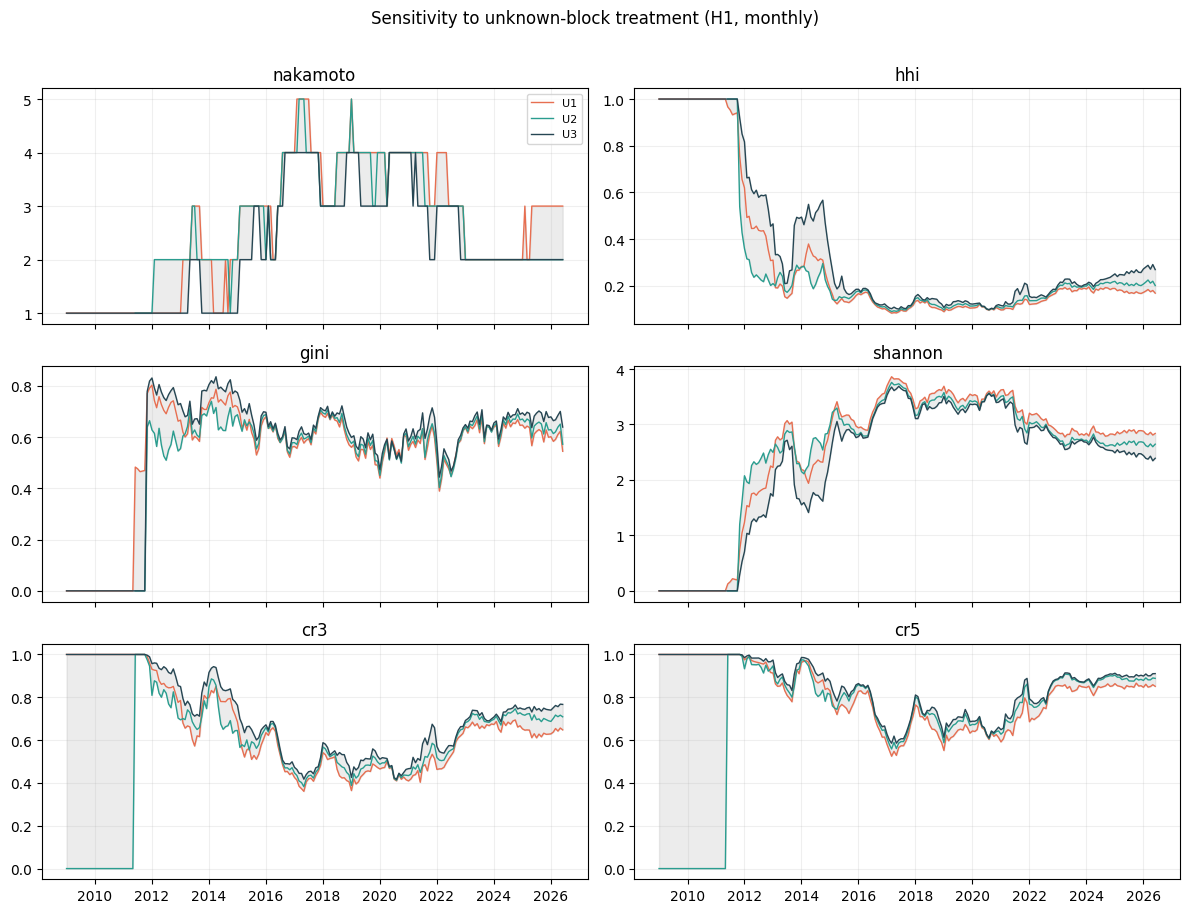

In [3]:
metrics = ["nakamoto", "hhi", "gini", "shannon", "cr3", "cr5"]
colors = {"U1": "#e76f51", "U2": "#2a9d8f", "U3": "#264653"}

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, metric in zip(axes.ravel(), metrics):
    p = sweep[sweep["metric"] == metric].pivot(index="window", columns="treatment", values="value")
    ax.fill_between(p.index, p.min(axis=1), p.max(axis=1), color="grey", alpha=0.15)
    for t in ["U1", "U2", "U3"]:
        ax.plot(p.index, p[t], color=colors[t], lw=1, label=t)
    ax.set_title(metric)
    ax.grid(alpha=0.2)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Sensitivity to unknown-block treatment (H1, monthly)", y=1.01)
fig.tight_layout()
import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/sensitivity_unknown.png", dpi=120, bbox_inches="tight")
plt.show()

## How wide are the bands and where?



In [4]:
def band_width(metric, year_from=None, year_to=None):
    p = sweep[sweep["metric"] == metric].pivot(index="window", columns="treatment", values="value")
    spread = (p.max(axis=1) - p.min(axis=1))
    mask = pd.Series(True, index=spread.index)
    if year_from is not None:
        mask &= spread.index.year >= year_from
    if year_to is not None:
        mask &= spread.index.year <= year_to
    return spread[mask].mean(), spread[mask].max()

print(f"{'metric':9}  {'mean band (all)':>16}  {'mean band (2018+)':>18}  {'max band (2018+)':>17}")
for m in metrics:
    all_mean, _ = band_width(m)
    rec_mean, rec_max = band_width(m, year_from=2018)
    print(f"{m:9}  {all_mean:16.3f}  {rec_mean:18.3f}  {rec_max:17.3f}")

metric      mean band (all)   mean band (2018+)   max band (2018+)
nakamoto              0.476               0.461              1.000
hhi                   0.072               0.037              0.111
gini                  0.061               0.040              0.094
shannon               0.300               0.233              0.465
cr3                   0.203               0.068              0.144
cr5                   0.180               0.053              0.114
